# Week 3

## Callbacks, tensorboard

In [ ]:
import tensorflow as tf
import datetime, os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
import os

In [ ]:
%load_ext tensorboard

In [ ]:
# Load MNIST dataset and preprocess
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
 # Build model/architecture
def create_model():
  return tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(28, 28)), #input layer
  tf.keras.layers.Flatten(), # flatten layer
  tf.keras.layers.Dense(128, activation='relu'), #hidden layer
  tf.keras.layers.Dense(10) #output layer: 10 nodes for 10 classes. Default activation: linear - relation to from_logits when compile model
])

In [ ]:
# NOTE
# # Model with softmax output
# model.add(Dense(10, activation='softmax'))  # Softmax is applied here

# # Compile the model
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

def train_model():

  model = create_model()

  model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # labels as integers
                metrics=['accuracy'])

  #Callbacks

  # 1. EarlyStopping: Stop training if the validation loss doesn't improve for 5 epochs
  early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  # 2. ModelCheckpoint: Save the best model during training
  checkpoint_filepath = 'logs/best_model.keras'  # Path to save the best model
  model_checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath,
                                    monitor='val_loss',
                                    save_best_only=True)

  # 3. ReduceLROnPlateau: Reduce the learning rate by a factor of 0.5 if validation loss doesn't improve for 3 epochs
  reduce_lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

  # 4. TensorBoard: Visualize training metrics with TensorBoard
  # log_dir = './logs'  # Directory to save TensorBoard logs
  # tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=1)
  logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  # print(logdir)
  tensorboard_callback = TensorBoard(logdir, histogram_freq=1)

  # Combine all the callbacks
  callbacks = [early_stopping_callback, model_checkpoint_callback, reduce_lr_callback, tensorboard_callback]

  # Train the model with the callbacks
  history = model.fit(x=x_train,
                      y=y_train,
                      epochs=10,
                      batch_size=32,
                      validation_data=(x_test, y_test),
                      callbacks=callbacks)
  # After training, you can load the best saved model
  best_model = tf.keras.models.load_model(checkpoint_filepath)

  return history, best_model

In [ ]:
help(ModelCheckpoint)

Help on class ModelCheckpoint in module keras.src.callbacks.model_checkpoint:

class ModelCheckpoint(keras.src.callbacks.callback.Callback)
 |  ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=False, save_weights_only=False, mode='auto', save_freq='epoch', initial_value_threshold=None)
 |  
 |  Callback to save the Keras model or model weights at some frequency.
 |  
 |  `ModelCheckpoint` callback is used in conjunction with training using
 |  `model.fit()` to save a model or weights (in a checkpoint file) at some
 |  interval, so the model or weights can be loaded later to continue the
 |  training from the state saved.
 |  
 |  A few options this callback provides include:
 |  
 |  - Whether to only keep the model that has achieved the "best performance" so
 |    far, or whether to save the model at the end of every epoch regardless of
 |    performance.
 |  - Definition of "best"; which quantity to monitor and whether it should be
 |    maximized or minimized.

In [ ]:
history, best_model = train_model()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8794 - loss: 0.4282 - val_accuracy: 0.9607 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9629 - loss: 0.1226 - val_accuracy: 0.9671 - val_loss: 0.1095 - learning_rate: 0.0010
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9755 - loss: 0.0813 - val_accuracy: 0.9700 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9818 - loss: 0.0609 - val_accuracy: 0.9764 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0438 - val_accuracy: 0.9801 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9890 - loss: 0.0351 - val_accuracy: 0.9775 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9925 - 

In [ ]:
%tensorboard --logdir logs

In [ ]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances

Known TensorBoard instances:
  - port 6006: logdir logs (started 0:03:37 ago; pid 3044)


In [ ]:
notebook.display(port=6006, height=1000)

## CNN - Layer Example

In [ ]:
# Convolutional layer
number_of_feature_maps = 64 # number of feature maps to be learned
kernel_size = 3 # size of the convolutional kernel
strides = 1 # number of pixels the kernel moves each time
padding = 'valid' # 'same - padding is applied' or 'valid - default - output dims are reduced based on kernel size'
# padding = 'same'
Conv2D = tf.keras.layers.Conv2D(number_of_feature_maps, kernel_size=kernel_size, strides=strides, padding=padding)
X = tf .random. uniform(shape=(1, 32, 32, 3)) #random data
# shape of X explained
# 32 x 32 size of image, 3 channels e.g. RGB
Y = Conv2D(X)
Y. shape #show output size

# number of parameters = 3^3 = 27 * 64 + 64 = 1792 vs FNN with 100 nodes 32*32*100+100= 102500 /409600

TensorShape([1, 30, 30, 64])

In [ ]:
Conv2D.weights #show weights


[<Variable path=conv2d/kernel, shape=(3, 3, 3, 64), dtype=float32, value=[[[[ 0.0738727   0.07763723  0.08442895 ... -0.00532178 -0.08294674
     -0.06879719]
    [ 0.07098822  0.03012389  0.04880421 ... -0.03680597 -0.05127357
     -0.03973928]
    [ 0.03649469 -0.05439802 -0.01712772 ... -0.07040474  0.0201961
      0.08562571]]
 
   [[-0.04240582  0.09868586  0.02321327 ...  0.03579892 -0.08556776
     -0.07159486]
    [ 0.02866621  0.07570657 -0.02758934 ... -0.01512442  0.01902648
     -0.05241039]
    [ 0.00152306 -0.08205987 -0.0964906  ...  0.02014652 -0.08482432
      0.04072778]]
 
   [[ 0.03878827 -0.06644194 -0.03107043 ... -0.04040626  0.09690234
     -0.06055682]
    [-0.04763994  0.02653472  0.00290772 ...  0.03930108  0.06787249
     -0.05429081]
    [-0.08815769 -0.09128551  0.06997566 ... -0.05392838  0.02869016
     -0.025958  ]]]
 
 
  [[[ 0.06672306 -0.09183456  0.01306738 ... -0.09079158  0.03556776
      0.09725751]
    [-0.04056382 -0.09893072  0.01261463 ...  0

In [ ]:
weights = Conv2D.get_weights()

# Separate kernel and bias
kernel, bias = weights

# Print the kernel (weights) as an array
print("Kernel weights:")
print(np.array(kernel[:,:,:,0]))

# Print the bias
print("\nBias:")
print(np.array(bias))

Kernel weights:
[[[ 0.0738727   0.07098822  0.03649469]
  [-0.04240582  0.02866621  0.00152306]
  [ 0.03878827 -0.04763994 -0.08815769]]

 [[ 0.06672306 -0.04056382 -0.05765724]
  [ 0.01761036 -0.06242567  0.03116806]
  [-0.08501681  0.0188766   0.06342658]]

 [[-0.09346627  0.01697403 -0.06417559]
  [-0.04410698  0.03881902 -0.02877187]
  [-0.09377797 -0.02832978  0.08259861]]]

Bias:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## get help on parameters for a layer

In [ ]:
help(tf.keras.layers.MaxPooling2D)


Help on class MaxPooling2D in module keras.src.layers.pooling.max_pooling2d:

class MaxPooling2D(keras.src.layers.pooling.base_pooling.BasePooling)
 |  MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid', data_format=None, name=None, **kwargs)
 |  
 |  Max pooling operation for 2D spatial data.
 |  
 |  Downsamples the input along its spatial dimensions (height and width)
 |  by taking the maximum value over an input window
 |  (of size defined by `pool_size`) for each channel of the input.
 |  The window is shifted by `strides` along each dimension.
 |  
 |  The resulting output when using the `"valid"` padding option has a spatial
 |  shape (number of rows or columns) of:
 |  `output_shape = math.floor((input_shape - pool_size) / strides) + 1`
 |  (when `input_shape >= pool_size`)
 |  
 |  The resulting output shape when using the `"same"` padding option is:
 |  `output_shape = math.floor((input_shape - 1) / strides) + 1`
 |  
 |  Args:
 |      pool_size: int or tuple of 2 i

## Training CNN

In [ ]:
# Importing necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load and prepare the CIFAR10 dataset
# CIFAR10 is a dataset of 60,000 32x32 color images in 10 classes
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


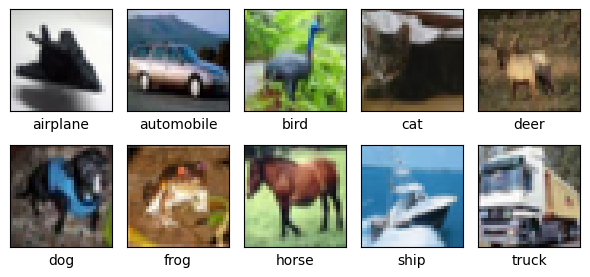

In [ ]:
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

# ---- pick one image per class ----
images = []
labels = []

for cls in range(10):
    idx = np.where(y_train.flatten() == cls)[0][0]
    images.append(X_train[idx])
    labels.append(class_names[cls])

# ---- plot ----
plt.figure(figsize=(6,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])
    plt.xlabel(labels[i])

plt.tight_layout()
plt.show()

In [ ]:
# Define a callback for Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Building the CNN model
model = models.Sequential()
model.add(layers.InputLayer(shape=(32, 32, 3)))  # Input layer for 32x32 colored images

# First convolutional layer
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='valid'))
# Batch Normalization to stabilize and accelerate training
# stabilize the learning process by normalizing the inputs to each layer. This means that the inputs to each layer have a mean of 0 and a standard deviation of 1.
# By normalizing the inputs, BatchNormalization allows for higher learning rates, which can speed up the training process. Higher learning rates can lead to faster convergence and reduce the time it takes to train a model.
# Reduces Sensitivity to Initialization - Neural networks can be sensitive to the initial weights. BatchNormalization reduces this sensitivity, making the training process more robust to different initializations
# Acts as a Regularizer - BatchNormalization introduces some noise into the training process by normalizing the inputs using the statistics of the current mini-batch. This noise acts as a form of regularization, reducing the need for other regularization techniques like dropout
# Improves Gradient Flow - By normalizing the inputs, BatchNormalization helps maintain a healthy gradient flow through the network. This can prevent issues like vanishing or exploding gradients, which are common in deep networks.
model.add(layers.BatchNormalization())


# MaxPooling to ...
# 1. Dimensionality Reduction
# MaxPooling2D reduces the spatial dimensions (width and height) of the input volume. This helps to decrease the number of parameters and computations in the network, making it more efficient and less prone to overfitting.
# 2. Translation Invariance
# By taking the maximum value in each pooling window, MaxPooling2D helps the network become more invariant to small translations of the input. This means that the network can recognize features regardless of their exact position in the input image.
# 3. Downsampling
# MaxPooling2D performs downsampling, which reduces the resolution of the feature maps. This allows the network to focus on the most important features and reduces the sensitivity to noise and small variations in the input.
# 4. Control Overfitting
# By reducing the spatial dimensions, MaxPooling2D helps to control overfitting. Smaller feature maps mean fewer parameters, which reduces the risk of the model memorizing the training data instead of generalizing to new data.

model.add(layers.MaxPooling2D((2, 2)))

# layers.MaxPooling2D((2, 2)): 2x2 pooling window, stride defaults to 2 (same as pool_size).
# layers.MaxPooling2D(pool_size=3, strides=1): 3x3 pooling window, stride of 1.
# layers.MaxPooling2D(pool_size=(4, 2), strides=(2, 1), padding='same'): 4x2 pooling window, stride of 2 vertically and 1 horizontally.

# Second convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Batch Normalization
model.add(layers.BatchNormalization())

# MaxPooling layer
model.add(layers.MaxPooling2D((2, 2)))

# Third convolutional layer
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
# Batch Normalization
model.add(layers.BatchNormalization())

# MaxPooling layer
model.add(layers.MaxPooling2D((2, 2)))

# Dropout for regularization, prevent overfitting
model.add(layers.Dropout(0.5))

# Flattening the output to feed into dense layers
model.add(layers.Flatten())

# Fully connected dense layer with 128 neurons
model.add(layers.Dense(128, activation='relu'))
# Batch Normalization
model.add(layers.BatchNormalization())
# Dropout for regularization
model.add(layers.Dropout(0.5))

# Output layer with 10 neurons for classification, softmax activation
model.add(layers.Dense(10, activation='softmax'))

# Summary of the model architecture
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,610 (631.29 KB)

 Trainable params: 160,906 (628.54 KB)

 Non-trainable params: 704 (2.75 KB)

## Model compile and fit(train)

Epoch 1/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6792 - loss: 0.9390 - val_accuracy: 0.6176 - val_loss: 1.1136
Epoch 2/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.6793 - loss: 0.9305 - val_accuracy: 0.5827 - val_loss: 1.2848
Epoch 3/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6909 - loss: 0.9123 - val_accuracy: 0.7166 - val_loss: 0.8178
Epoch 4/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7047 - loss: 0.8711 - val_accuracy: 0.7187 - val_loss: 0.8245
Epoch 5/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7139 - loss: 0.8465 - val_accuracy: 0.7411 - val_loss: 0.7492
Epoch 6/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.7200 - loss: 0.8285 - val_accuracy: 0.7243 - val_loss: 0.8081
Epoch 7/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7260 - loss: 0.8045 - val_accuracy: 0.6944 - val_loss: 0.8666
Epoch 8/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.7288 -

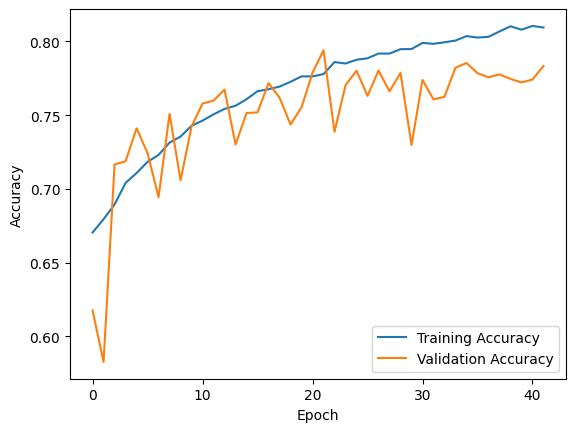

313/313 - 2s - 5ms/step - accuracy: 0.7940 - loss: 0.6042
Test accuracy: 0.7940


In [ ]:

# Compile the model
# We will define a custom learning rate in the Adam optimizer
learning_rate = 0.003  # You can experiment with this value
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)


model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
batch_size = 16  # You can experiment with different batch sizes (e.g., 32, 128, etc.)
history = model.fit(X_train, y_train, epochs=100,
                    batch_size=batch_size,  # Tune batch size here
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping],
                    shuffle=True) # default

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")


## Visualize feature maps

In [ ]:
print(model.layers[0].name)  # Output: 'conv_1'


conv2d_7


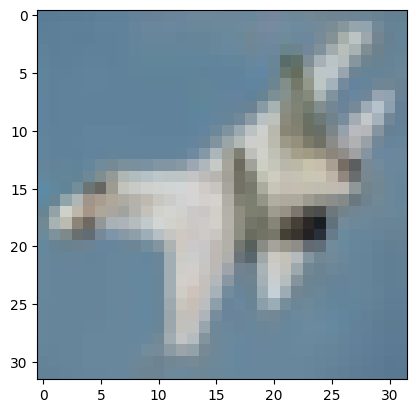

(1, 30, 30, 32) feature shape


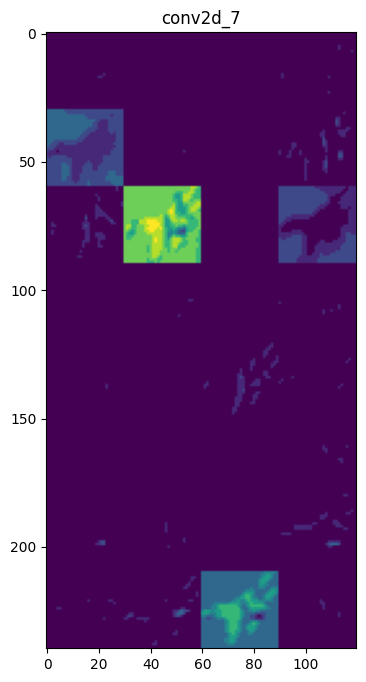

In [ ]:
# Select a layer to visualize
layer_name = model.layers[0].name  # Example: Second convolutional layer, try 0, 3, 6, etc

# Get the layer from the model
layer = model.get_layer(name=layer_name)

# Create a feature extraction model
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=layer.output)

# Choose an image from the test set
image = X_test[10]  # Example: First image in the test set
plt.imshow(image)
plt.show()
# Expand dimensions to create a batch of size 1
image = tf.expand_dims(image, axis=0)

# Get the features for the chosen image
features = feature_extractor(image)

# Visualize the features
import numpy as np

n_features = features.shape[-1]
size = features.shape[1]
print(features.shape, 'feature shape')
n_cols = 8  # Number of columns in the grid
display_grid = np.zeros((size * n_cols, size * (n_features // n_cols)))

for col in range(n_cols):
    for row in range(n_features // n_cols):
        channel_image = features[0, :, :, col * (n_features // n_cols) + row]
        # channel_image -= tf.math.reduce_mean(channel_image)
        # channel_image /= tf.math.reduce_std(channel_image)
        # channel_image *= 64
        # channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')
        display_grid[col * size : (col + 1) * size, row * size : (row + 1) * size] = channel_image

scale = 1. / size
plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
plt.title(layer_name)
plt.grid(False)
plt.imshow(display_grid, aspect='auto', cmap='viridis')
plt.show()

## Bulding models using API

However, although sequential
models are extremely common, it is sometimes useful to build neural networks with
more complex topologies, or with multiple inputs or outputs. For this purpose, Keras
offers the Functional API.

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(28, 28)), #input layer
  tf.keras.layers.Flatten(), # flatten layer
  tf.keras.layers.Dense(128, activation='relu'), #hidden layer
  tf.keras.layers.Dense(10) #output layer: 10 nodes for 10 classes. Default activation: linear - relation to from_logits wehn compile model
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model

# Input layer: shape (28, 28)
inputs = Input(shape=(28, 28))

# Flatten layer: reshapes (28, 28) to a vector of shape (784,)
x = Flatten()(inputs)

# Hidden Dense layer with 128 neurons and ReLU activation
x = Dense(128, activation='relu')(x)

# Output Dense layer with 10 neurons and softmax activation
outputs = Dense(10, activation='softmax')(x)

# Define the model using the functional API
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Bulding Complex architectures

![](https://drive.google.com/uc?export=view&id=1fEZ4FaJL8crB6FnScKx60LtYYz-DILfl)


In [ ]:
input = tf.keras.layers.Input(shape=(60,), name = 'input')
hidden1 = tf.keras.layers.Dense(30, activation="relu", name = 'Hidden1')(input)
hidden2 = tf.keras.layers.Dense(30, activation="relu", name = 'Hidden2')(hidden1)
concat = tf.keras.layers.Concatenate(name = 'concat')([input, hidden2])
output = tf.keras.layers.Dense(1, name = 'output')(concat)
model = tf.keras.models.Model(inputs=[input], outputs=[output])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)        │ (None, 60)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Hidden1 (Dense)           │ (None, 30)             │          1,830 │ input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Hidden2 (Dense)           │ (None, 30)             │            930 │ Hidden1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concat (Concatenate)      │ (None, 90)             │              0 │ input[0][0],           │
│                           │                        │                │ Hidden2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             91 │ concat[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

![](https://drive.google.com/uc?export=view&id=1S5YcRQ7awe3eJUqwz9LPmObz_8hN1WUQ)


In [ ]:
#assumes
# X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
# X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]

input_A = tf.keras.layers.Input(shape=[5], name = 'inputA')
input_B = tf.keras.layers.Input(shape=[6], name = 'inputB')
hidden1 = tf.keras.layers.Dense(30, activation="relu", name = 'Hidden1')(input_B)
hidden2 = tf.keras.layers.Dense(30, activation="relu", name = 'Hidden2')(hidden1)
concat = tf.keras.layers.Concatenate(name = 'concat')([input_A, hidden2])
output = tf.keras.layers.Dense(1, name = 'output')(concat)
model = tf.keras.models.Model(inputs=[input_A, input_B], outputs=[output])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ inputB (InputLayer)       │ (None, 6)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Hidden1 (Dense)           │ (None, 30)             │            210 │ inputB[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inputA (InputLayer)       │ (None, 5)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Hidden2 (Dense)           │ (None, 30)             │            930 │ Hidden1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concat (Concatenate)      │ (None, 35)             │              0 │ inputA[0][0],          │
│                           │                        │                │ Hidden2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             36 │ concat[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,176 (4.59 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 0 (0.00 B)

![](https://drive.google.com/uc?export=view7id=1fEZ4FaJL8crB6FnScKx60LtYYz-DILfl)

![](https://drive.google.com/uc?export=view7id=1S5YcRQ7awe3eJUqwz9LPmObz_8hN1WUQ)


#Practical code

## Crossvalidation

In [ ]:
(X, y), _ = datasets.mnist.load_data()
print("Data shape (X_train):", X.shape)
print("Labels shape (y_train):", y.shape)

Data shape (X_train): (60000, 28, 28)
Labels shape (y_train): (60000,)


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
fold = 1

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # model = Sequential([...])  # Define your model here
    # model.compile([...])       # Compile your model here
    model = create_model()

    model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])


    # Use ModelCheckpoint for each fold
    checkpoint = ModelCheckpoint(f'best_model_fold_{fold}.keras', monitor='val_loss', save_best_only=True, mode='min')

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, callbacks=[checkpoint])

    fold += 1


Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7901 - loss: 8.8364 - val_accuracy: 0.8915 - val_loss: 0.4959
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9012 - loss: 0.4096 - val_accuracy: 0.9066 - val_loss: 0.3783
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9258 - loss: 0.2836 - val_accuracy: 0.9160 - val_loss: 0.3309
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9318 - loss: 0.2604 - val_accuracy: 0.9204 - val_loss: 0.3150
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9362 - loss: 0.2366 - val_accuracy: 0.9342 - val_loss: 0.2769
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9427 - loss: 0.2183 - val_accuracy: 0.9406 - val_loss: 0.2769
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9455 - loss: 0.2143 - val_accuracy: 0.9350 - val_loss: 0.2988
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9501 - loss: 0.1986 - 

## Listing Layers

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

# Example model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# List all layers in the model
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name} - {layer.__class__.__name__}")


Layer 0: conv2d_4 - Conv2D
Layer 1: flatten_9 - Flatten
Layer 2: dense_18 - Dense
Layer 3: dense_19 - Dense


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Image augmentation example - pseudo code

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the path to the train and validation folders
train_path = '/content/drive/MyDrive/your_data/train'
val_path = '/content/drive/MyDrive/your_data/val'

# Create an ImageDataGenerator for data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load the training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Load the validation data
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=25,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

In [ ]:

# this is how to mount google drive to be usable and reachable as data storage
from google.colab import drive
drive.mount('/content/drive')
# convert colab nb to html
%%shell
jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/INN/Week-3/W3.ipynb


SyntaxError: invalid syntax (ipython-input-2246938038.py, line 6)